In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

In [2]:
df = pd.read_csv('../data/processed/cleaned_shots.csv')
df

,minute,second,period,team_name,player_name,position_name,x,y,end_x,end_y,...,play_pattern_name,under_pressure,shot_first_time,shot_one_on_one,shot_open_goal,shot_deflected,shot_statsbomb_xg,outcome_name,season_name,goal
0,0,18,1,Switzerland,Granit Xhaka,Left Defensive Midfield,96.0,38.8,108.2,38.5,...,From Kick Off,False,True,False,False,False,0.036566,Blocked,2022,0
1,0,22,1,Switzerland,Breel-Donald Embolo,Center Forward,113.1,40.7,114.8,40.6,...,From Kick Off,False,True,False,False,False,0.353289,Saved,2022,0
2,0,23,1,Switzerland,Granit Xhaka,Left Defensive Midfield,103.8,41.9,115.5,39.1,...,From Kick Off,False,True,False,False,False,0.069527,Saved,2022,0
3,4,35,1,Serbia,Nikola Milenković,Right Center Back,112.2,36.8,120.0,35.3,...,From Corner,False,False,False,False,False,0.081609,Off T,2022,0
4,10,5,1,Serbia,Andrija Živković,Right Wing Back,97.8,51.5,120.0,36.1,...,Regular Play,False,False,False,False,False,0.030002,Post,2022,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,76,9,2,Egypt,Amr Medhat Warda,Center Attacking Midfield,102.0,22.0,112.0,36.0,...,From Goal Kick,False,False,False,False,False,0.028970,Blocked,2018,0
3196,80,4,2,Saudi Arabia,Mohammed Al Burayk,Right Back,95.0,30.0,104.0,32.0,...,From Free Kick,False,False,False,False,False,0.065623,Blocked,2018,0
3197,80,57,2,Saudi Arabia,Salem Mohammed Al Dawsari,Center Attacking Midfield,116.0,30.0,119.0,36.8,...,From Throw In,False,True,False,False,False,0.088908,Saved,2018,0
3198,90,30,2,Saudi Arabia,Abdullah Ibrahim Otayf,Center Defensive Midfield,101.0,58.0,106.0,52.0,...,Regular Play,True,False,False,False,False,0.020325,Blocked,2018,0


In [3]:
df.shape


(3200, 22)

In [5]:
df['goal'].value_counts(normalize=True)

goal
0    0.881875
1    0.118125
Name: proportion, dtype: float64

In [6]:
df['outcome_name'].value_counts()

outcome_name
Off T               1020
Blocked              836
Saved                687
Goal                 378
Wayward              214
Post                  60
Saved to Post          3
Saved Off Target       2
Name: count, dtype: int64

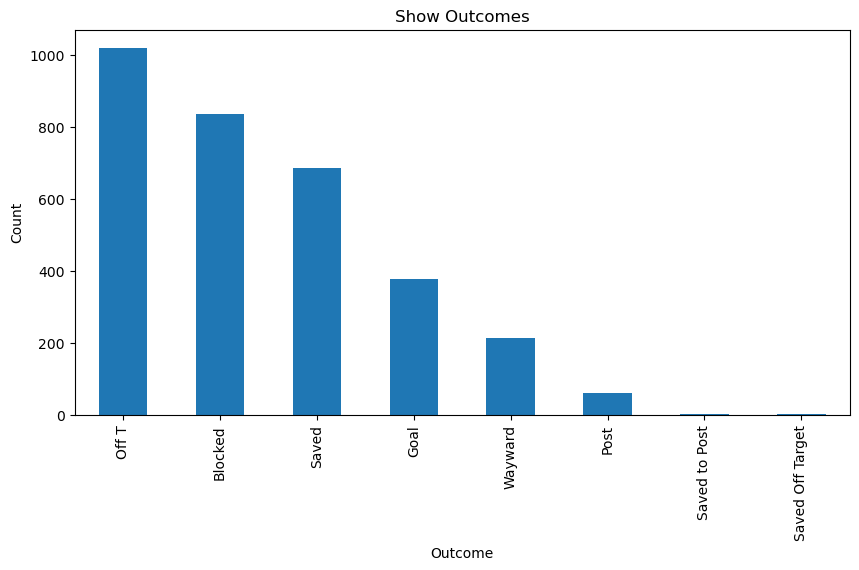

In [10]:
df['outcome_name'].value_counts().plot(
    kind='bar',
    figsize = (10,5)
)

plt.title("Show Outcomes")
plt.xlabel('Outcome')
plt.ylabel('Count')

plt.show()

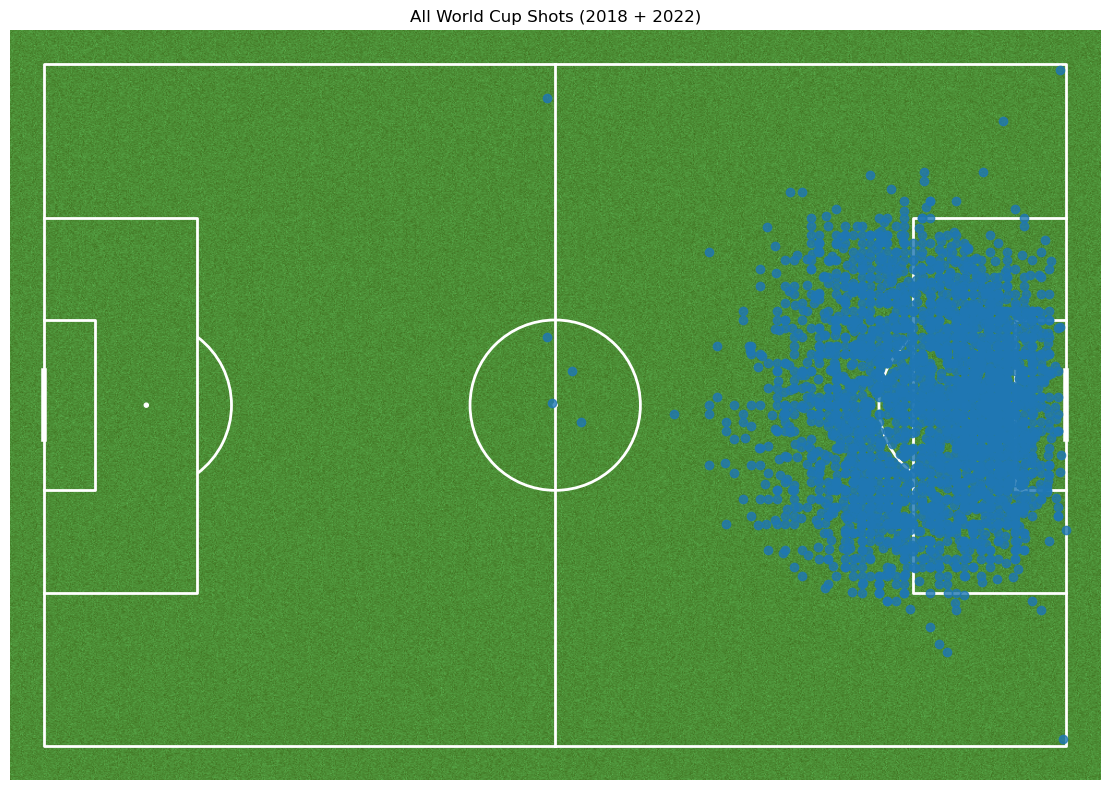

In [18]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='grass',
    line_color='white'
)

fig, ax = pitch.draw(figsize=(12, 8))

pitch.scatter(
    df['x'],
    df['y'],
    ax=ax,
    alpha = 0.8
)

ax.set_title("All World Cup Shots (2018 + 2022)")

plt.show()

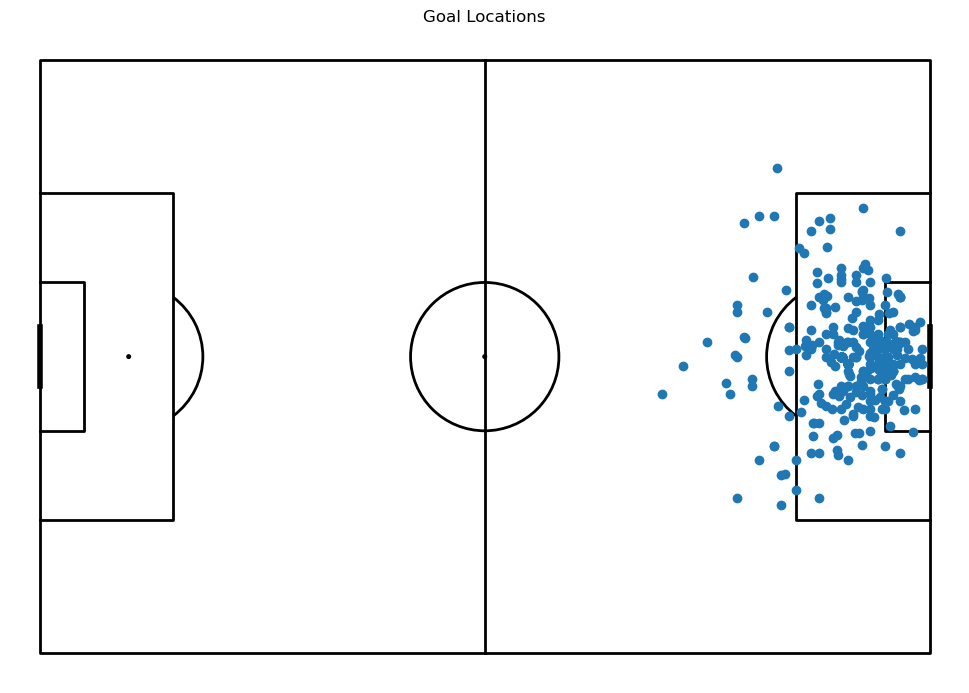

In [14]:
goals = df[df['goal'] == 1]
pitch = Pitch(
    pitch_type = 'statsbomb',
    pitch_color= 'white',
    line_color = 'black'
)

fig, ax = pitch.draw(figsize=(10,7))

pitch.scatter(
    goals['x'],
    goals['y'],
    ax = ax
)

plt.title('Goal Locations')
plt.show()

In [19]:
df['body_part_name'].value_counts()


body_part_name
Right Foot    1662
Left Foot      949
Head           562
Other           27
Name: count, dtype: int64

In [20]:
df.groupby('body_part_name')['goal'].mean()

body_part_name
Head          0.106762
Left Foot     0.114858
Other         0.148148
Right Foot    0.123345
Name: goal, dtype: float64

In [21]:
df.groupby('under_pressure')['goal'].mean()

under_pressure
False    0.127231
True     0.075838
Name: goal, dtype: float64

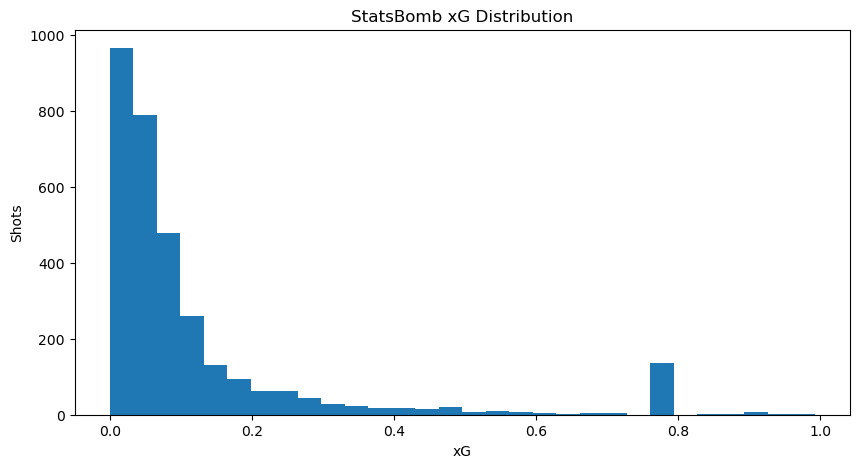

In [23]:
plt.figure(figsize=(10,5))

plt.hist(
    df['shot_statsbomb_xg'],
    bins=30
)

plt.title("StatsBomb xG Distribution")
plt.xlabel("xG")
plt.ylabel("Shots")

plt.show()